In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import cv2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/monkeytype/monkeytyping.csv')
df.head()

,participant_id,date,original_filename,trial_number,reaction_time,correct,correct_position,chosen_position,prompt,sample_name,...,file_path,stimuli_quantity,colored,nut_quantity,juice_quantity,datetime,mean_reaction_time,percent_correct,omission_percent,experiment_duration
0,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,1,1029,0,2th,3th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
1,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,2,579,1,2th,2th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
2,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,3,688,0,3th,4th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
3,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,4,578,0,4th,2th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
4,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,5,848,1,4th,4th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"


In [ ]:
df_symbols = df[df['colored'].isna()].copy(deep=True)
df_symbols = df_symbols[df_symbols['file_3_name'].notna()].copy(deep=True)
df_symbols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5339 entries, 0 to 6158
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   participant_id             5339 non-null   object 
 1   date                       5339 non-null   object 
 2   original_filename          5339 non-null   object 
 3   trial_number               5339 non-null   int64  
 4   reaction_time              5339 non-null   object 
 5   correct                    5339 non-null   int64  
 6   correct_position           5339 non-null   object 
 7   chosen_position            5339 non-null   object 
 8   prompt                     0 non-null      float64
 9   sample_name                0 non-null      float64
 10  file_1_name                5339 non-null   object 
 11  file_2_name                5339 non-null   object 
 12  file_3_name                5339 non-null   object 
 13  file_4_name                5339 non-null   object 
 1

In [ ]:
image_filepath_main = '/content/drive/MyDrive/monkeytype/emnist_rare_ESRGAN_improved/'
file_cols_name = ['file_1_name', 'file_2_name', 'file_3_name', 'file_4_name']
file_names_from_csv = []
file_names_real_paths = []
for f in file_cols_name:
  df_symbols[f] = df_symbols[f].astype(str)
  for index, row in df_symbols.iterrows():
    df_symbols.loc[index, f] = df_symbols.loc[index, f][0] + '/'+df_symbols.loc[index, f][2:] + '_out.png'
print(df_symbols[file_cols_name[0]])

0       y/00902_out.png
1       s/00320_out.png
2       c/01270_out.png
3       f/00745_out.png
4       s/01180_out.png
             ...       
6154    f/01252_out.png
6155    m/01187_out.png
6156    m/00439_out.png
6157    m/00413_out.png
6158    c/00117_out.png
Name: file_1_name, Length: 5339, dtype: object


In [ ]:
df_files = df_symbols[file_cols_name].copy(deep = True)
df_files.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5339 entries, 0 to 6158
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   file_1_name  5339 non-null   object
 1   file_2_name  5339 non-null   object
 2   file_3_name  5339 non-null   object
 3   file_4_name  5339 non-null   object
dtypes: object(4)
memory usage: 337.6+ KB


In [ ]:
for index, row in df_files.iterrows():
  for f in file_cols_name:
    file_names_from_csv.append(df_files.loc[index, f][0])

print(set(file_names_from_csv))

{'m', 'c', 's', 'y', 'f', 'j'}


In [ ]:
for index, row in df_files.iterrows():
  for f in file_cols_name:
    df_files.loc[index, f] = image_filepath_main + df_files.loc[index, f]

df_files.head()

,file_1_name,file_2_name,file_3_name,file_4_name
0,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...
1,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...
2,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...
3,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...
4,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...


In [ ]:
#собираем статиистику средних яркостей и выборы
bright_images = []
chosen_vectors = []

for index, row in df_files.iterrows():
  brights_images_per_session = []
  index_ch = df_symbols.loc[index, 'chosen_position'][0]
  if index_ch!="N":
    vectorc = np.eye(4)[int(index_ch)-1]
    for f in file_cols_name:
      img = cv2.imread(df_files.loc[index, f], cv2.IMREAD_GRAYSCALE)
      if img is None:
        print(f"Ошибка: не удалось загрузить изображение по пути: {df_files.loc[index, f]}")
      brights_images_per_session.append(np.mean(img))
    bright_images.append(brights_images_per_session)
    chosen_vectors.append(vectorc)
  if index%100==0:
    print(index)
    print(bright_images[-1])
    print(chosen_vectors[-1])


0
[np.float64(46.31776147959184), np.float64(35.22217793367347), np.float64(35.28085140306123), np.float64(52.36352040816327)]
[0. 0. 1. 0.]
100
[np.float64(36.87739158163265), np.float64(64.8897480867347), np.float64(31.776785714285715), np.float64(64.05062181122449)]
[1. 0. 0. 0.]
200
[np.float64(35.02056760204081), np.float64(16.854033801020407), np.float64(30.69013073979592), np.float64(43.52925701530612)]
[0. 0. 1. 0.]
300
[np.float64(35.65776466836735), np.float64(22.653539540816325), np.float64(26.928970025510203), np.float64(43.48804209183673)]
[0. 0. 1. 0.]
400
[np.float64(44.077806122448976), np.float64(23.281329719387756), np.float64(48.009885204081634), np.float64(58.5891262755102)]
[0. 1. 0. 0.]
500
[np.float64(35.76419005102041), np.float64(43.360331632653065), np.float64(40.86025191326531), np.float64(50.7805325255102)]
[0. 0. 1. 0.]
600
[np.float64(47.908561862244895), np.float64(72.8125), np.float64(37.425701530612244), np.float64(25.344467474489797)]
[0. 0. 1. 0.]
700

In [ ]:
from scipy.stats import pearsonr
corrs = []
for i in range(len(bright_images)):
  a = np.array(chosen_vectors[i])
  b = np.array(bright_images[i])
  corr, _ = pearsonr(a, b)
  corrs.append(corr)

In [ ]:
corrs_arr = np.array(corrs)
print(corrs_arr)
# число наблюдений (корреляций)
n = len(corrs_arr)

# Fisher Z преобразование
z = np.arctanh(corrs_arr)

# среднее z
z_mean = np.mean(z)

# стандартная ошибка z
# формула: SE = 1 / sqrt(N - 3)
se = 1 / np.sqrt(n - 3)

# 95% доверительный интервал в z-пространстве
z_low  = z_mean - 1.96 * se
z_high = z_mean + 1.96 * se

# обратное преобразование в r-пространство
r_mean = np.tanh(z_mean)
r_low  = np.tanh(z_low)
r_high = np.tanh(z_high)

print("Агрегированная корреляция (Fisher Z):", r_mean)
print("95% ДИ:", (r_low, r_high))

[-5.50174746e-01 -7.66682672e-01  4.34197582e-01 ... -5.62665833e-01
  5.95033152e-04 -3.64416954e-01]
Агрегированная корреляция (Fisher Z): 0.27357125985616493
95% ДИ: (np.float64(0.24683988453228234), np.float64(0.29988661467974187))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1. ПОДГОТОВКА ДАННЫХ
# -----------------------------

# Преобразуем выборы в метки классов 0–3
y = np.argmax(chosen_vectors, axis=1)

# Преобразуем яркости в матрицу X
X = np.array(bright_images)

# -----------------------------
# 2. РАЗБИВКА НА ТРЕНИРОВКУ / ТЕСТ
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# -----------------------------
# 3. ОБУЧЕНИЕ МОДЕЛИ
# -----------------------------
model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=500
)

model.fit(X_train, y_train)

# -----------------------------
# 4. ОЦЕНКА МОДЕЛИ
# -----------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nКлассификационные метрики:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# 5. КОЭФФИЦИЕНТЫ
# -----------------------------
print("\nКоэффициенты логистической регрессии:")
print(model.coef_)
print("\nСмещения (bias):")
print(model.intercept_)

#— это матрица 4×4:

#строки: классы (0,1,2,3 — выбранное изображение)

#столбцы: влияние яркости каждого изображения

#Например: model.coef_[0,2] = -0.00271546
#если яркость первого изображения растёт на 1 единицу,
#то лог-вероятность выбора третьего уменьшается на 0.002.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.509090909090909

Классификационные метрики:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       106
           1       0.52      0.71      0.60       419
           2       0.49      0.54      0.52       329
           3       0.00      0.00      0.00        81

    accuracy                           0.51       935
   macro avg       0.25      0.31      0.28       935
weighted avg       0.41      0.51      0.45       935


Коэффициенты логистической регрессии:
[[ 0.00244779 -0.01472772 -0.00271546 -0.00269187]
 [-0.00296057  0.02956858 -0.00847584 -0.00556452]
 [-0.00549125 -0.01355027  0.0290855  -0.01331848]
 [ 0.00600404 -0.0012906  -0.0178942   0.02157487]]

Смещения (bias):
[ 0.10014882  0.33861655  0.69743416 -1.13619952]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import scipy.stats as stats
t, p = stats.ttest_1samp(corrs_arr, 0)
print(p)

3.0878356871308946e-103


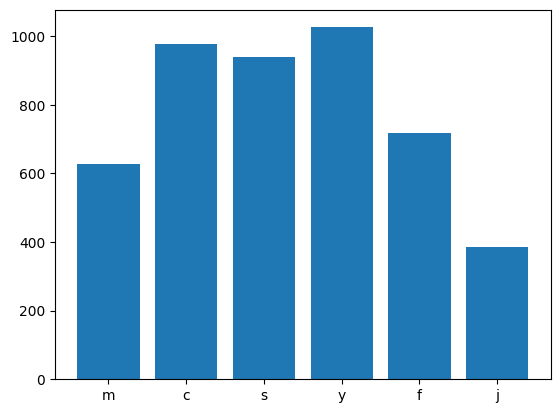

In [ ]:
symbols_cols = ['m', 'c', 's', 'y', 'f', 'j']
n_rows = 1
df_sym_hist = pd.DataFrame(np.zeros((n_rows, len(symbols_cols))),columns=symbols_cols)
for index, row in df_symbols.iterrows():
  f = ''
  index_ch = df_symbols.loc[index, 'chosen_position'][0]
  if index_ch!="N":
    for i, s in enumerate(file_cols_name):
      if index_ch in s:
        f = file_cols_name[i]
    symbol2count = df_symbols.loc[index, f][0]
    df_sym_hist.loc[0, symbol2count]+=1.0

values = df_sym_hist.iloc[0]
fig, ax = plt.subplots()
ax.bar(values.index, values.values, label=values.values)

plt.show()
